## Phylogenetic tree and correlation matrix


In [1]:
!git clone https://github.com/glottolog/glottolog-cldf

Cloning into 'glottolog-cldf'...
remote: Enumerating objects: 369, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 369 (delta 1), reused 1 (delta 1), pack-reused 361 (from 2)
Receiving objects: 100% (369/369), 299.56 MiB | 22.40 MiB/s, done.
Resolving deltas: 100% (222/222), done.


In [2]:
%cd glottolog-cldf/


/content/glottolog-cldf


In [3]:
%cd cldf

/content/glottolog-cldf/cldf


In [4]:
!ls

classification.nex  languages.csv  parameters.csv    sources.bib.zip
cldf-metadata.json  media.csv	   README.md	     trees.csv
codes.csv	    names.csv	   requirements.txt  values.csv


In [5]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.4 MB/s eta 0:00:00


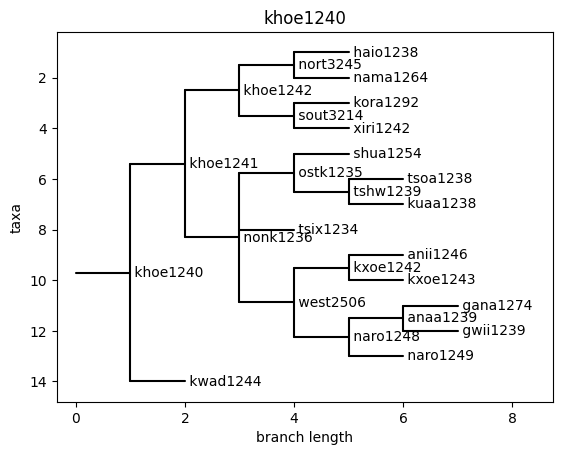

In [6]:
from Bio import Phylo

trees = Phylo.parse("classification.nex", "nexus")

trees_dictionary = dict()
for tree in trees:

    trees_dictionary[tree.name] = tree
    #Phylo.draw(tree)
Phylo.draw(trees_dictionary['khoe1240'])

In [7]:

'uruc1242'
'east1459'

'east1459'

In [8]:
path = trees_dictionary['khoe1240'].get_path('naro1248')
path

[Clade(branch_length=1.0, name='khoe1241'),
 Clade(branch_length=1.0, name='nonk1236'),
 Clade(branch_length=1.0, name='west2506'),
 Clade(branch_length=1.0, name='naro1248')]

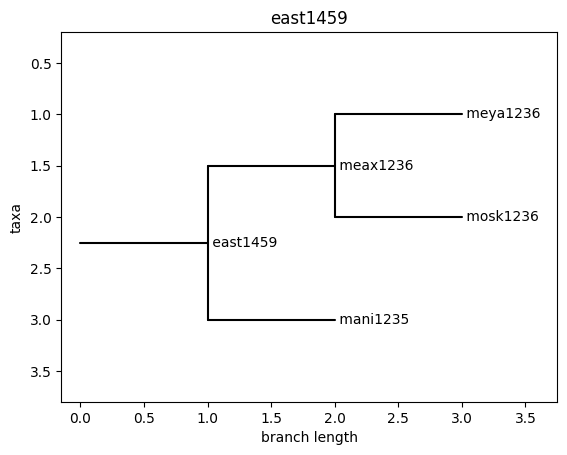

In [9]:
from Bio import Phylo
from Bio.Phylo.BaseTree import Clade, Tree
tree1 = trees_dictionary['east1459']
tree2 = trees_dictionary['uruc1242']
Phylo.draw(tree1)




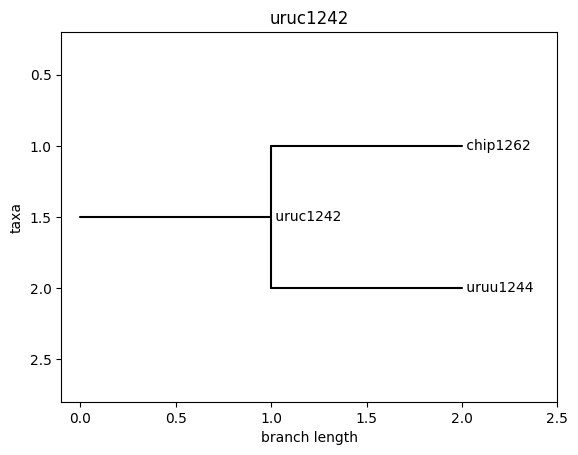

In [10]:
Phylo.draw(tree2)

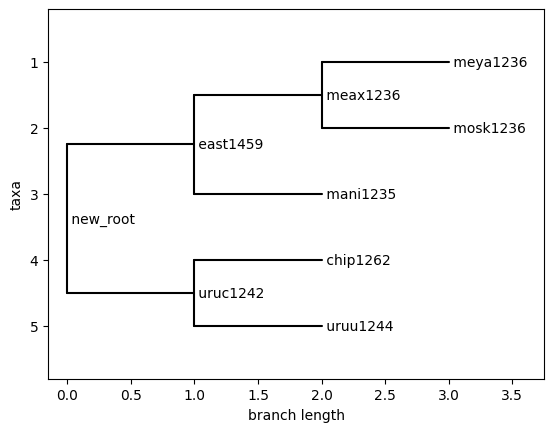

In [11]:
new_root = Clade(name="new_root")

# Attach the original roots as children
new_root.clades.append(tree1.root)
new_root.clades.append(tree2.root)

# Create the new combined tree
combined_tree = Tree(root=new_root)
Phylo.draw(combined_tree)


In [12]:
print(combined_tree)

Tree(rooted=True)
    Clade(name='new_root')
        Clade(branch_length=1.0, name='east1459')
            Clade(branch_length=1.0, name='meax1236')
                Clade(branch_length=1.0, name='meya1236')
                Clade(branch_length=1.0, name='mosk1236')
            Clade(branch_length=1.0, name='mani1235')
        Clade(branch_length=1.0, name='uruc1242')
            Clade(branch_length=1.0, name='chip1262')
            Clade(branch_length=1.0, name='uruu1244')


In [13]:
mrca = combined_tree.common_ancestor("meya1236", "uruu1244")
mrca

Clade(name='new_root')

In [14]:
Metaroot = Clade(name="Metaroot")
for tree in trees_dictionary.values():
  tree.root.branch_length = 1
  Metaroot.clades.append(tree.root)
Meta_tree = Tree(root=Metaroot)
#Phylo.draw(combined_tree)

In [15]:
Phylo.write(Meta_tree, "Meta_tree.nwk", "newick")

1

In [16]:
from google.colab import files

files.download('Meta_tree.nwk')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
#print(Meta_tree)

In [18]:
mrca = Meta_tree.common_ancestor("tson1249",
"lozi1239")
mrca

Clade(branch_length=1.0, name='dims1234')

In [19]:
distance = Meta_tree.distance(Meta_tree.root, mrca)

print("MRCA:", mrca.name)
print("Distance from root:", distance)

MRCA: dims1234
Distance from root: 10.0


In [20]:
languages = [
"nama1265",
"tson1249",
"lozi1239",
"umbu1257",
"suku1259",
"nyak1261",
"lugu1238",
"kiku1240",
"gand1255",
"bila1255",
"tivv1240",
"nucl1417",
"haus1257",
"shil1265",
"amha1245",
"akka1240",
"nucl1301",
"gheg1238",
"lati1261",
"iris1253",
"nort2671",
"nene1249",
"russ1263",
"nucl1235",
"cent1972",
"west2386",
"toda1252",
"kaza1248",
"halh1238",
"nucl1310",
"lame1256",
"carn1240",
"java1254",
"bali1278",
"iban1264",
"abui1241",
"kima1246",
"ekar1243",
"kwom1262",
"tita1241",
"kili1267",
"siwa1245",
"tiko1237",
"saaa1241",
"maor1246",
"nort2845",
"samo1305",
"pala1344",
"atay1247",
"kore1280",
"nucl1643",
"sout2959",
"eyak1241",
"nort2938",
"yuro1248",
"east2545",
"nort1551",
"coma1245",
"zuni1245",
"toho1246",
"huic1243",
"wayu1243",
"mund1330",
"cube1242",
"cusc1236",
"cent2142",
"siri1273",
"trum1247",
"tupi1273",
"mbya1239",
"mapu1245",
"tehu1242"
]

In [21]:
language_is_not_present = [Meta_tree.find_any(name=language)==None for language in languages]
language_is_not_present


[True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False]

In [22]:
final_languages = []
deleted_languages = []
for i in range(len(language_is_not_present)):
  if language_is_not_present[i]:
    deleted_languages.append(languages[i])
  if not language_is_not_present[i]:
    final_languages.append(languages[i])
final_languages = sorted( final_languages)
final_languages
#sorted(deleted_languages)

['abui1241',
 'akka1240',
 'amha1245',
 'atay1247',
 'bali1278',
 'bila1255',
 'carn1240',
 'cent1972',
 'cent2142',
 'coma1245',
 'cube1242',
 'cusc1236',
 'east2545',
 'ekar1243',
 'eyak1241',
 'gand1255',
 'gheg1238',
 'halh1238',
 'haus1257',
 'huic1243',
 'iban1264',
 'iris1253',
 'java1254',
 'kaza1248',
 'kiku1240',
 'kili1267',
 'kima1246',
 'kore1280',
 'kwom1262',
 'lame1256',
 'lati1261',
 'lozi1239',
 'lugu1238',
 'maor1246',
 'mapu1245',
 'mbya1239',
 'mund1330',
 'nene1249',
 'nort2671',
 'nort2845',
 'nort2938',
 'nucl1235',
 'nucl1301',
 'nucl1310',
 'nucl1417',
 'nucl1643',
 'pala1344',
 'russ1263',
 'saaa1241',
 'samo1305',
 'shil1265',
 'siri1273',
 'siwa1245',
 'sout2959',
 'suku1259',
 'tehu1242',
 'tiko1237',
 'tita1241',
 'tivv1240',
 'toda1252',
 'tson1249',
 'tupi1273',
 'umbu1257',
 'wayu1243',
 'west2386',
 'yuro1248']

In [23]:
languages_correlation_matrix = dict()
for language1 in final_languages:
  for language2 in final_languages:
    mrca = Meta_tree.common_ancestor(language1,language2)
    distance = Meta_tree.distance(Meta_tree.root, mrca)
    languages_correlation_matrix[(language1,language2)] = distance

languages_correlation_matrix


{('abui1241', 'abui1241'): 6.0,
 ('abui1241', 'akka1240'): 0,
 ('abui1241', 'amha1245'): 0,
 ('abui1241', 'atay1247'): 0,
 ('abui1241', 'bali1278'): 0,
 ('abui1241', 'bila1255'): 0,
 ('abui1241', 'carn1240'): 0,
 ('abui1241', 'cent1972'): 0,
 ('abui1241', 'cent2142'): 0,
 ('abui1241', 'coma1245'): 0,
 ('abui1241', 'cube1242'): 0,
 ('abui1241', 'cusc1236'): 0,
 ('abui1241', 'east2545'): 0,
 ('abui1241', 'ekar1243'): 0,
 ('abui1241', 'eyak1241'): 0,
 ('abui1241', 'gand1255'): 0,
 ('abui1241', 'gheg1238'): 0,
 ('abui1241', 'halh1238'): 0,
 ('abui1241', 'haus1257'): 0,
 ('abui1241', 'huic1243'): 0,
 ('abui1241', 'iban1264'): 0,
 ('abui1241', 'iris1253'): 0,
 ('abui1241', 'java1254'): 0,
 ('abui1241', 'kaza1248'): 0,
 ('abui1241', 'kiku1240'): 0,
 ('abui1241', 'kili1267'): 0,
 ('abui1241', 'kima1246'): 0,
 ('abui1241', 'kore1280'): 0,
 ('abui1241', 'kwom1262'): 0,
 ('abui1241', 'lame1256'): 0,
 ('abui1241', 'lati1261'): 0,
 ('abui1241', 'lozi1239'): 0,
 ('abui1241', 'lugu1238'): 0,
 ('abui1

In [24]:
import pandas as pd
df = pd.Series(languages_correlation_matrix).unstack()

In [25]:
df

,abui1241,akka1240,amha1245,atay1247,bali1278,bila1255,carn1240,cent1972,cent2142,coma1245,...,tiko1237,tita1241,tivv1240,toda1252,tson1249,tupi1273,umbu1257,wayu1243,west2386,yuro1248
abui1241,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
akka1240,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
amha1245,0.0,2.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
atay1247,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bali1278,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tupi1273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0
umbu1257,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,6.0,0.0,11.0,0.0,0.0,0.0
wayu1243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
west2386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0


In [26]:
import numpy as np
C = np.array(df)
C

array([[ 6.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  4.,  2., ...,  0.,  0.,  0.],
       [ 0.,  2.,  7., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  4.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0., 10.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  2.]])

In [27]:
df.to_csv("data.csv", index=False)

In [28]:

files.download('data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## PGLS statistics

In [38]:
#value_kin_terminology = [
109, 152, 176, 42, 162, 204, 62, 182, 164, 251, 294, 268, 153, 114, 91,
181, 180, 114, 417, 20, 162, 366, 162, 183, 222, 96, 114, 230, 114, 8,
154, 182, 242, 110, 342, 214, 148, 108, 250, 145, 104, 314, 176, 110,
124, 212, 118, 162, 107, 196, 262, 271, 114, 226, 336, 278, 162, 293,
186, 392, 186, 216, 228, 188, 488, 158
#]


value_kin_terminology = [109, 152, 176, 42, 162, 204, 62, 182, 164, 251, 294, 268, 153, 114, 91, 181, 180, 114, 417, 20, 162, 366, 162, 183, 222, 96, 112, 198, 114, 8, 154, 182, 242, 110, 342, 202, 148, 108, 140, 145, 104, 314, 176, 110, 124, 212, 118, 162, 107, 196, 100, 271, 80, 226, 336, 278, 195, 134, 186, 392, 186, 216, 228, 188, 488, 158]

#diff = [value_kin_terminology[i] - value_kin_terminology_2[i] for i in range(len(value_kin_terminology))]
#diff

In [39]:
value_avoidance = [
0, 1, 1, 0, 1, 0, 999, 0, 1, 999, 999, 0, 0, 1, 999, 0, 999, 1, 999, 0,
1, 1, 999, 1, 999, 1, 999, 1, 999, 999, 1, 999, 1, 1, 1, 1, 999, 1,
999, 999, 999, 1, 1, 0, 0, 0, 1, 999, 999, 1, 999, 999, 1, 1, 0, 1, 1,
999, 1, 1, 0, 0, 0, 1, 1, 999
]
value_avoidance_converted = []
for value in value_avoidance:
  if value == 0:
    value_avoidance_converted.append('No avoidance')
  if value ==1:
    value_avoidance_converted.append('Avoiance')
  if value ==999:
    value_avoidance_converted.append('No info')
  if value == 444:
    value_avoidance_converted.append('Mixed')
value_avoidance = value_avoidance_converted
value_avoidance

['No avoidance',
 'Avoiance',
 'Avoiance',
 'No avoidance',
 'Avoiance',
 'No avoidance',
 'No info',
 'No avoidance',
 'Avoiance',
 'No info',
 'No info',
 'No avoidance',
 'No avoidance',
 'Avoiance',
 'No info',
 'No avoidance',
 'No info',
 'Avoiance',
 'No info',
 'No avoidance',
 'Avoiance',
 'Avoiance',
 'No info',
 'Avoiance',
 'No info',
 'Avoiance',
 'No info',
 'Avoiance',
 'No info',
 'No info',
 'Avoiance',
 'No info',
 'Avoiance',
 'Avoiance',
 'Avoiance',
 'Avoiance',
 'No info',
 'Avoiance',
 'No info',
 'No info',
 'No info',
 'Avoiance',
 'Avoiance',
 'No avoidance',
 'No avoidance',
 'No avoidance',
 'Avoiance',
 'No info',
 'No info',
 'Avoiance',
 'No info',
 'No info',
 'Avoiance',
 'Avoiance',
 'No avoidance',
 'Avoiance',
 'Avoiance',
 'No info',
 'Avoiance',
 'Avoiance',
 'No avoidance',
 'No avoidance',
 'No avoidance',
 'Avoiance',
 'Avoiance',
 'No info']

In [40]:
value_languages = dict()
for i in range(len(final_languages)):
  value_languages[final_languages[i]] = [final_languages[i],value_kin_terminology[i],value_avoidance[i]]
value_languages

{'abui1241': ['abui1241', 109, 'No avoidance'],
 'akka1240': ['akka1240', 152, 'Avoiance'],
 'amha1245': ['amha1245', 176, 'Avoiance'],
 'atay1247': ['atay1247', 42, 'No avoidance'],
 'bali1278': ['bali1278', 162, 'Avoiance'],
 'bila1255': ['bila1255', 204, 'No avoidance'],
 'carn1240': ['carn1240', 62, 'No info'],
 'cent1972': ['cent1972', 182, 'No avoidance'],
 'cent2142': ['cent2142', 164, 'Avoiance'],
 'coma1245': ['coma1245', 251, 'No info'],
 'cube1242': ['cube1242', 294, 'No info'],
 'cusc1236': ['cusc1236', 268, 'No avoidance'],
 'east2545': ['east2545', 153, 'No avoidance'],
 'ekar1243': ['ekar1243', 114, 'Avoiance'],
 'eyak1241': ['eyak1241', 91, 'No info'],
 'gand1255': ['gand1255', 181, 'No avoidance'],
 'gheg1238': ['gheg1238', 180, 'No info'],
 'halh1238': ['halh1238', 114, 'Avoiance'],
 'haus1257': ['haus1257', 417, 'No info'],
 'huic1243': ['huic1243', 20, 'No avoidance'],
 'iban1264': ['iban1264', 162, 'Avoiance'],
 'iris1253': ['iris1253', 366, 'Avoiance'],
 'java1254

In [41]:
df = pd.DataFrame(value_languages).T
df.columns = ['language','richness', 'avoidance']
df

,language,richness,avoidance
abui1241,abui1241,109,No avoidance
akka1240,akka1240,152,Avoiance
amha1245,amha1245,176,Avoiance
atay1247,atay1247,42,No avoidance
bali1278,bali1278,162,Avoiance
...,...,...,...
tupi1273,tupi1273,216,No avoidance
umbu1257,umbu1257,228,No avoidance
wayu1243,wayu1243,188,Avoiance
west2386,west2386,488,Avoiance


In [42]:
X = pd.get_dummies(df["avoidance"])



X

,Avoiance,No avoidance,No info
abui1241,False,True,False
akka1240,True,False,False
amha1245,True,False,False
atay1247,False,True,False
bali1278,True,False,False
...,...,...,...
tupi1273,False,True,False
umbu1257,False,True,False
wayu1243,True,False,False
west2386,True,False,False


In [43]:
import statsmodels.api as sm
import numpy as np

df["richness"] = pd.to_numeric(df["richness"])
# Convert boolean columns in X to integer type for statsmodels
X_numeric = X.astype(int)
model = sm.GLS(df["richness"], X_numeric, sigma=C)
results = model.fit()

In [44]:
print(results.summary())

                            GLS Regression Results                            
Dep. Variable:               richness   R-squared:                       0.094
Model:                            GLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     3.281
Date:                Sun, 03 May 2026   Prob (F-statistic):             0.0441
Time:                        13:32:19   Log-Likelihood:                -386.55
No. Observations:                  66   AIC:                             779.1
Df Residuals:                      63   BIC:                             785.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Avoiance       196.1139     16.850     11.639   

In [36]:
df.to_csv("richness_avoidance.csv", index=False)
files.download("richness_avoidance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>